In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load processed dataset
df_a = pd.read_csv("../data/processed/house_price_processed.csv")

print("Shape:", df_a.shape)
print("Columns:", df_a.columns.tolist())

FIG_DIR = "../reports/figures"
print("Using figure folder:", FIG_DIR)

Shape: (14620, 34)
Columns: ['id', 'Date', 'number of bedrooms', 'number of bathrooms', 'living area', 'lot area', 'number of floors', 'waterfront present', 'number of views', 'condition of the house', 'grade of the house', 'Area of the house(excluding basement)', 'Area of the basement', 'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude', 'Longitude', 'living_area_renov', 'lot_area_renov', 'Number of schools nearby', 'Distance from the airport', 'Price', 'Sale_Date', 'Sale_Year', 'Sale_Month', 'Sale_Quarter', 'Property_Age', 'Renovated', 'Basement_Percentage', 'schools_norm', 'airport_norm', 'grade_norm', 'Infrastructure_Score']
Using figure folder: ../reports/figures


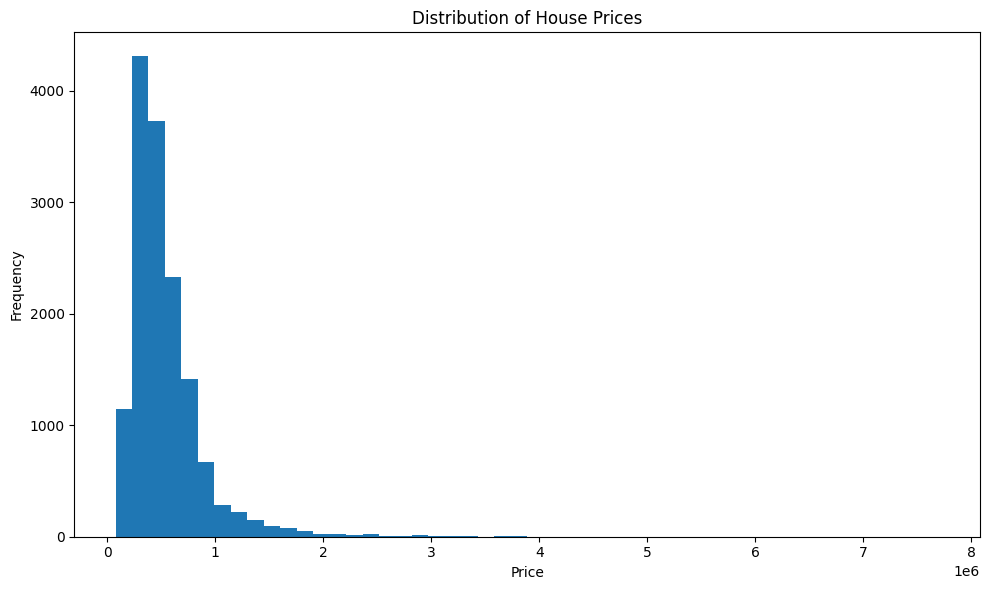

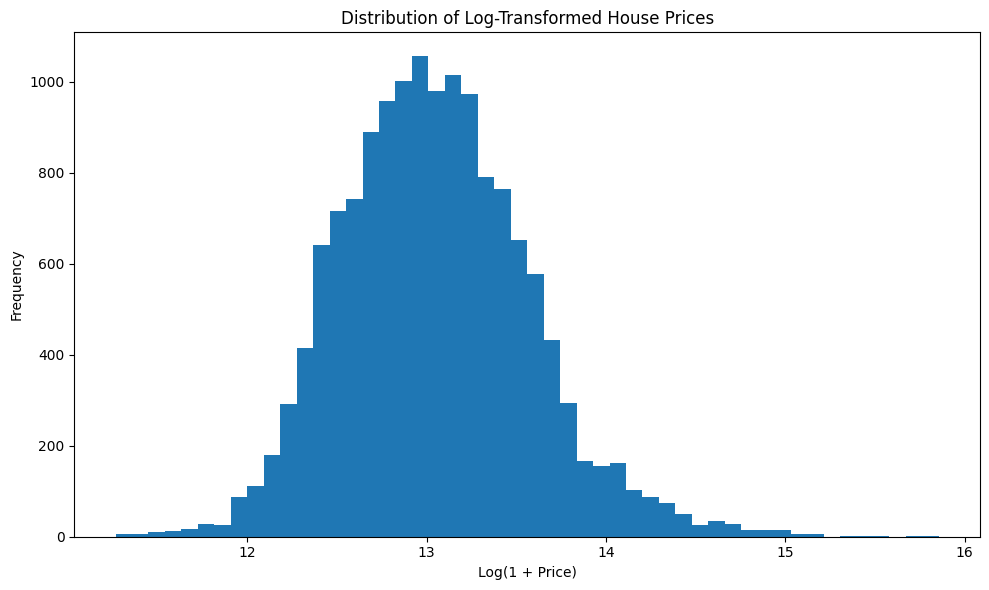

count    1.462000e+04
mean     5.389322e+05
std      3.675324e+05
min      7.800000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: Price, dtype: float64

Price skewness: 4.269297720707116

Log_Price skewness: 0.42485845447418114


In [2]:
# Create log-transformed price for EDA only
df_a["Log_Price"] = np.log1p(df_a["Price"])

# -----------------------------
# 1) Raw Price Distribution
# -----------------------------
plt.figure(figsize=(10, 6))
plt.hist(df_a["Price"], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 2) Log Price Distribution
# -----------------------------
plt.figure(figsize=(10, 6))
plt.hist(df_a["Log_Price"], bins=50)
plt.title("Distribution of Log-Transformed House Prices")
plt.xlabel("Log(1 + Price)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/log_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# quick numeric check
print(df_a["Price"].describe())
print("\nPrice skewness:", df_a["Price"].skew())
print("\nLog_Price skewness:", df_a["Log_Price"].skew())

# Living area, bedrooms, bathrooms distribution

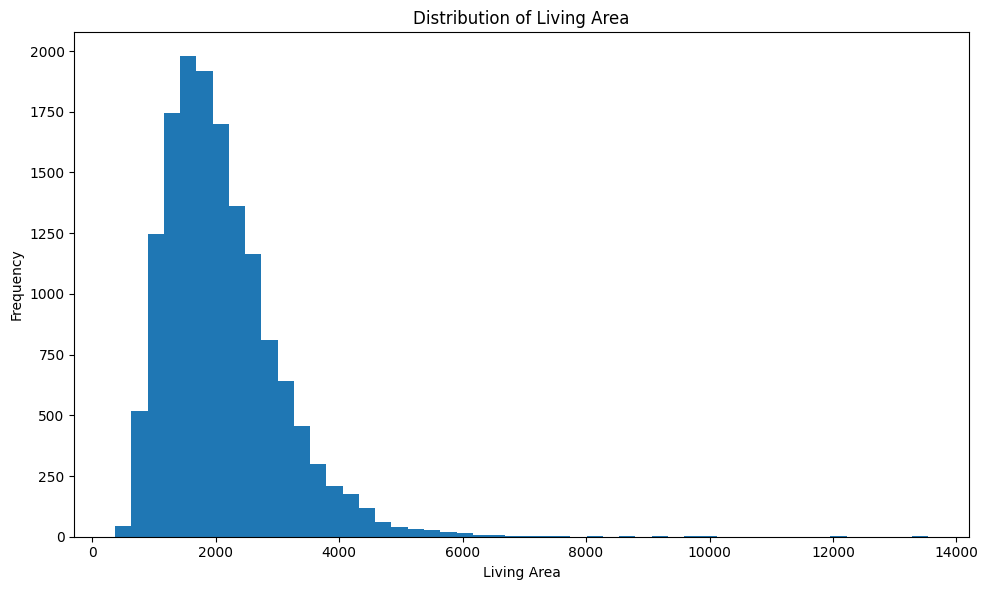

Living Area Summary:
count    14620.000000
mean      2098.262996
std        928.275721
min        370.000000
25%       1440.000000
50%       1930.000000
75%       2570.000000
max      13540.000000
Name: living area, dtype: float64
Living Area Skewness: 1.538336624376669


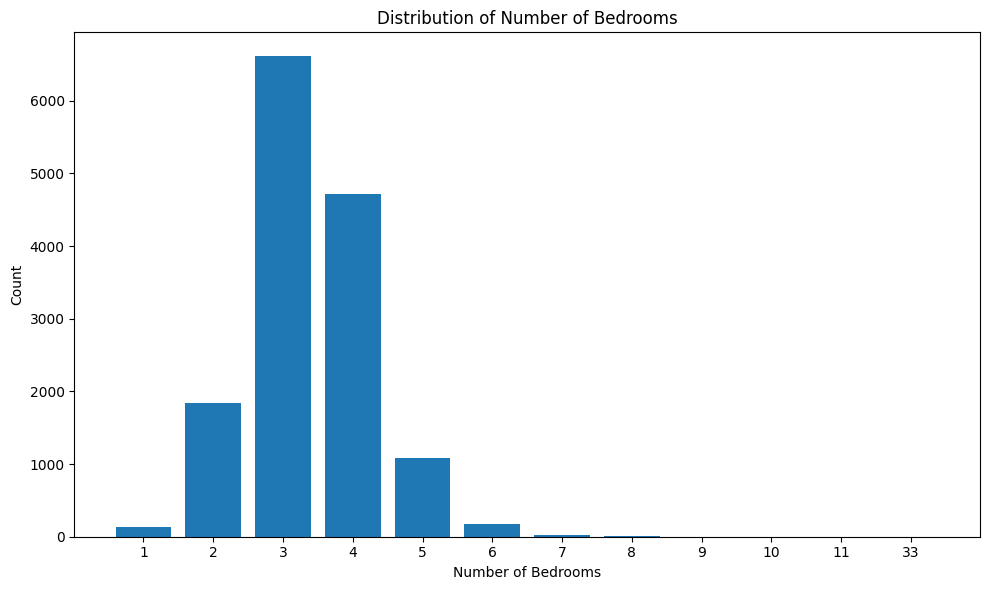


Bedrooms Value Counts:
number of bedrooms
1      136
2     1844
3     6612
4     4724
5     1079
6      176
7       30
8       11
9        3
10       3
11       1
33       1
Name: count, dtype: int64


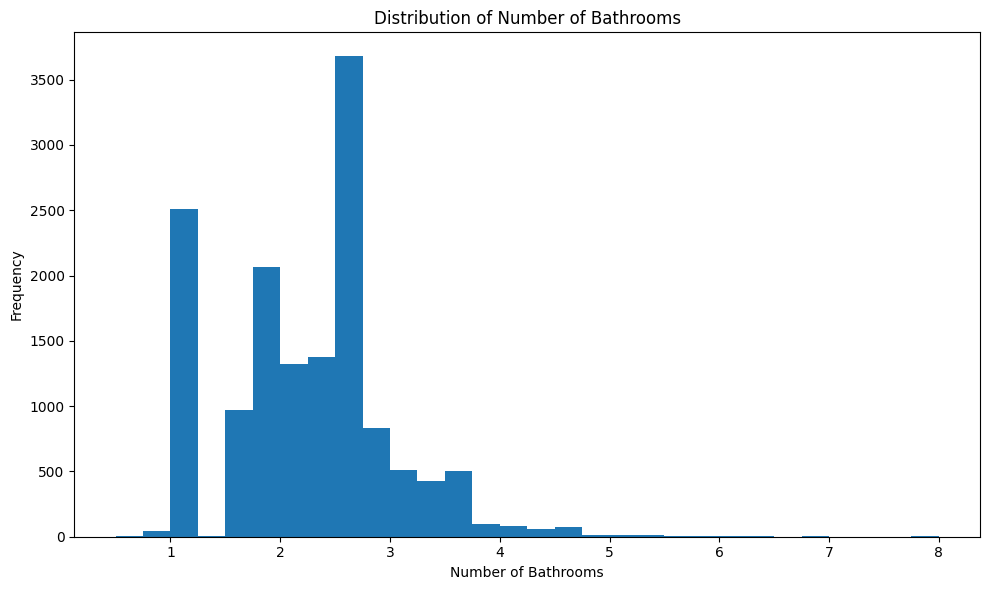


Bathrooms Summary:
count    14620.000000
mean         2.129583
std          0.769934
min          0.500000
25%          1.750000
50%          2.250000
75%          2.500000
max          8.000000
Name: number of bathrooms, dtype: float64
Bathrooms Skewness: 0.5566631395086086


In [3]:
# 1) Living Area Distribution

plt.figure(figsize=(10, 6))
plt.hist(df_a["living area"], bins=50)
plt.title("Distribution of Living Area")
plt.xlabel("Living Area")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/living_area_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Living Area Summary:")
print(df_a["living area"].describe())
print("Living Area Skewness:", df_a["living area"].skew())



# 2) Bedrooms Distribution

bedroom_counts = df_a["number of bedrooms"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(bedroom_counts.index.astype(str), bedroom_counts.values)
plt.title("Distribution of Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/bedrooms_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nBedrooms Value Counts:")
print(bedroom_counts)



# 3) Bathrooms Distribution

plt.figure(figsize=(10, 6))
plt.hist(df_a["number of bathrooms"], bins=30)
plt.title("Distribution of Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/bathrooms_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nBathrooms Summary:")
print(df_a["number of bathrooms"].describe())
print("Bathrooms Skewness:", df_a["number of bathrooms"].skew())

Grade, Condition, Postal Code distributions

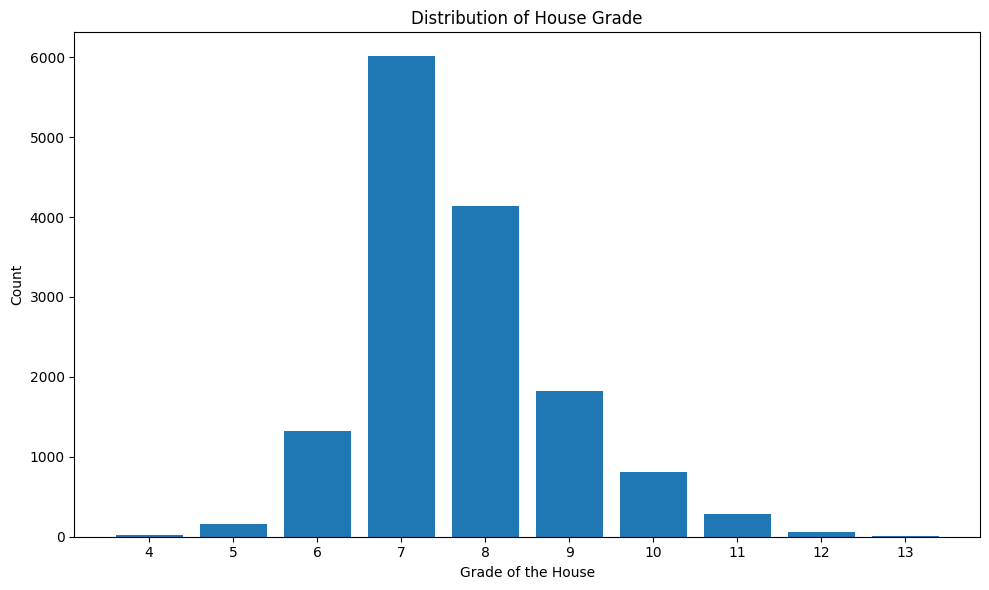

Grade Value Counts:
grade of the house
4       17
5      154
6     1324
7     6011
8     4137
9     1828
10     804
11     280
12      55
13      10
Name: count, dtype: int64


In [4]:
# 1) Grade Distribution
grade_counts = df_a["grade of the house"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(grade_counts.index.astype(str), grade_counts.values)
plt.title("Distribution of House Grade")
plt.xlabel("Grade of the House")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/grade_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Grade Value Counts:")
print(grade_counts)

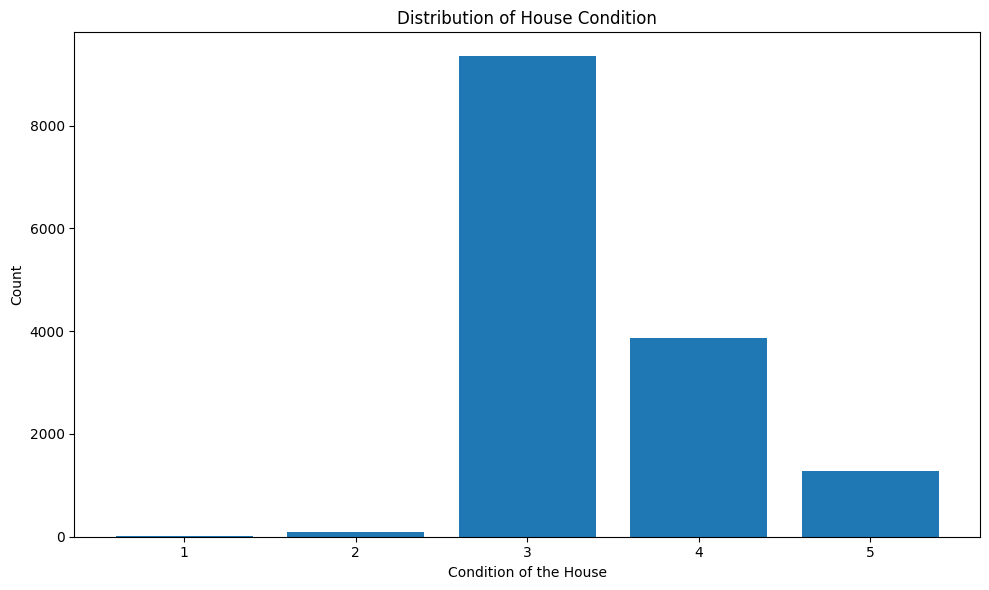


Condition Value Counts:
condition of the house
1      18
2     100
3    9350
4    3874
5    1278
Name: count, dtype: int64


In [5]:
# 2) Condition Distribution
condition_counts = df_a["condition of the house"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(condition_counts.index.astype(str), condition_counts.values)
plt.title("Distribution of House Condition")
plt.xlabel("Condition of the House")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/condition_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nCondition Value Counts:")
print(condition_counts)


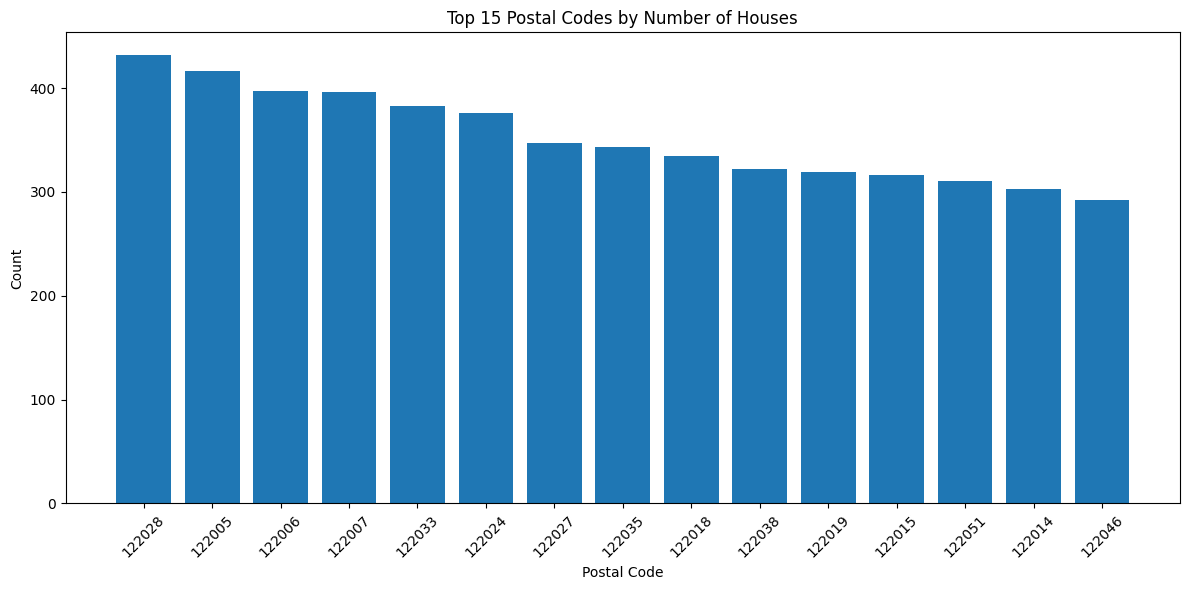


Top 15 Postal Codes:
Postal Code
122028    432
122005    416
122006    397
122007    396
122033    383
122024    376
122027    347
122035    343
122018    335
122038    322
122019    319
122015    316
122051    310
122014    303
122046    292
Name: count, dtype: int64


In [6]:
# 3) Top Postal Codes Distribution
postal_counts = df_a["Postal Code"].value_counts().head(15)

plt.figure(figsize=(12, 6))
plt.bar(postal_counts.index.astype(str), postal_counts.values)
plt.title("Top 15 Postal Codes by Number of Houses")
plt.xlabel("Postal Code")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/top_postal_codes_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nTop 15 Postal Codes:")
print(postal_counts)

# starting the bivariate eda

Living area vs Price, Bedrooms vs Price, Bathrooms vs Price

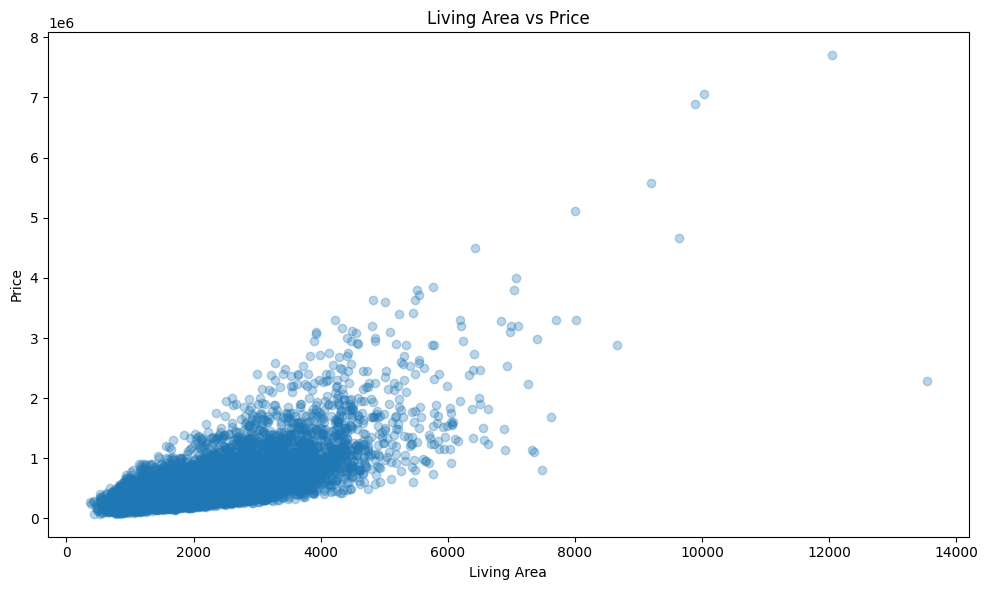

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df_a["living area"], df_a["Price"], alpha=0.3)
plt.title("Living Area vs Price")
plt.xlabel("Living Area")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/living_area_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

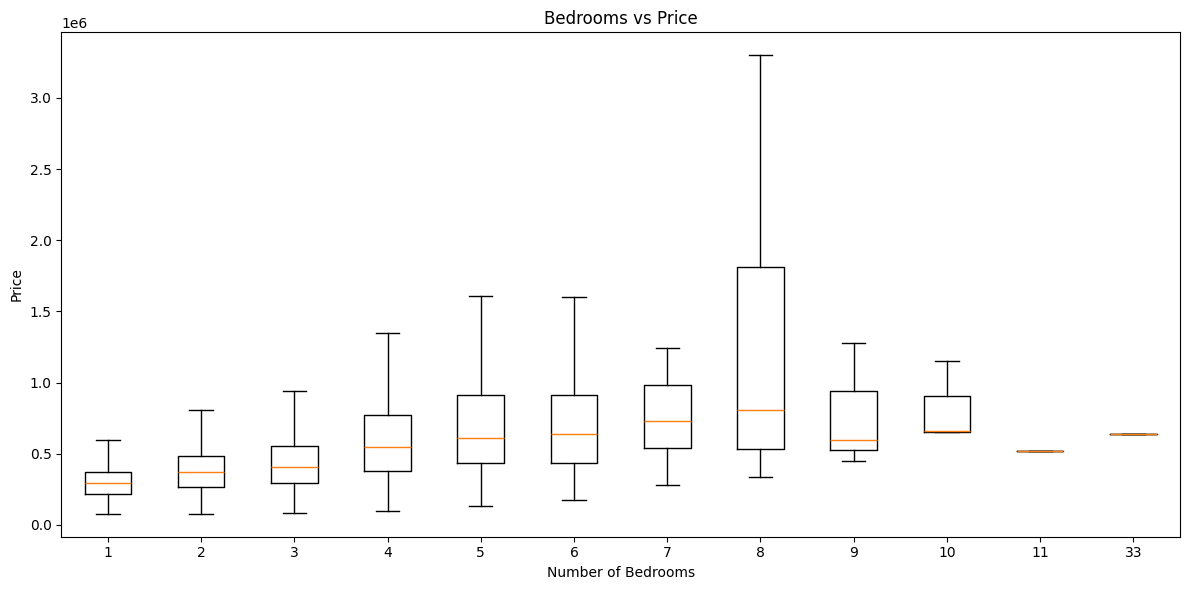

In [8]:
bedroom_order = sorted(df_a["number of bedrooms"].unique())
bedroom_price_data = [
    df_a.loc[df_a["number of bedrooms"] == b, "Price"] for b in bedroom_order
]

plt.figure(figsize=(12, 6))
plt.boxplot(bedroom_price_data, tick_labels=[str(b) for b in bedroom_order], showfliers=False)
plt.title("Bedrooms vs Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/bedrooms_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

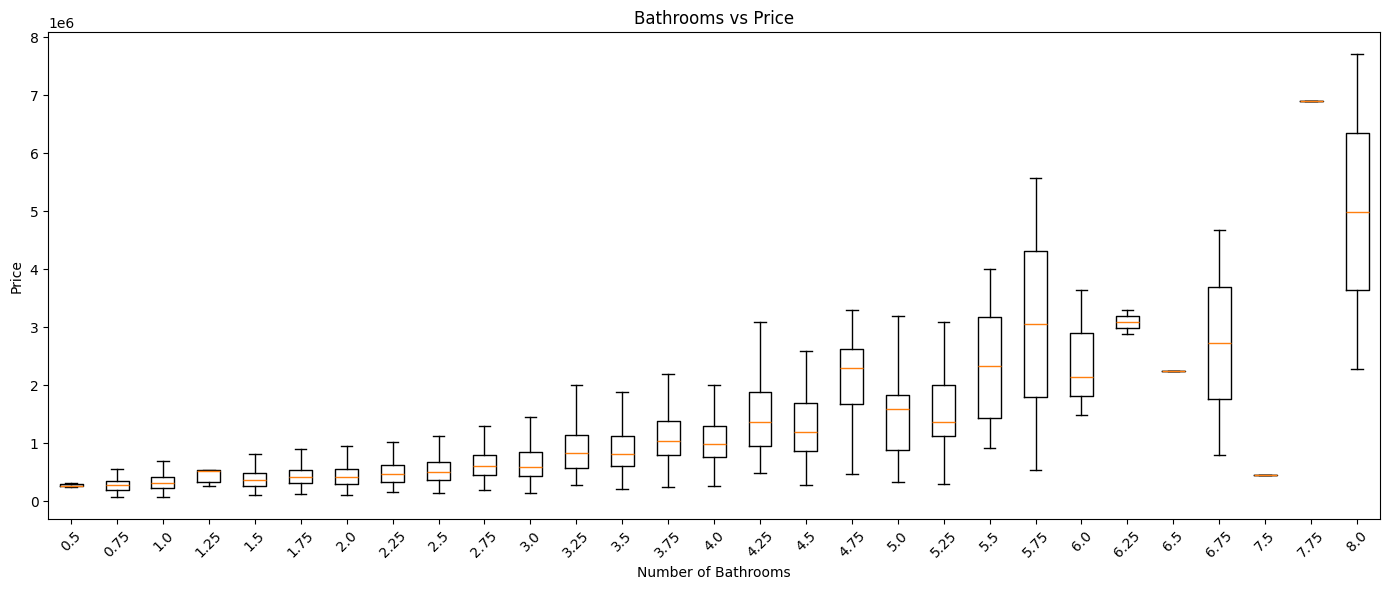

In [9]:
bathroom_order = sorted(df_a["number of bathrooms"].unique())
bathroom_price_data = [
    df_a.loc[df_a["number of bathrooms"] == b, "Price"] for b in bathroom_order
]

plt.figure(figsize=(14, 6))
plt.boxplot(bathroom_price_data, tick_labels=[str(b) for b in bathroom_order], showfliers=False)
plt.title("Bathrooms vs Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/bathrooms_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


In [10]:
# quick numeric support
print("Correlation with Price:")
print(df_a[["living area", "number of bedrooms", "number of bathrooms", "Price"]].corr()["Price"].sort_values(ascending=False))

Correlation with Price:
Price                  1.000000
living area            0.712169
number of bathrooms    0.531735
number of bedrooms     0.308460
Name: Price, dtype: float64


Grade, Condition, Waterfront, Views vs Price

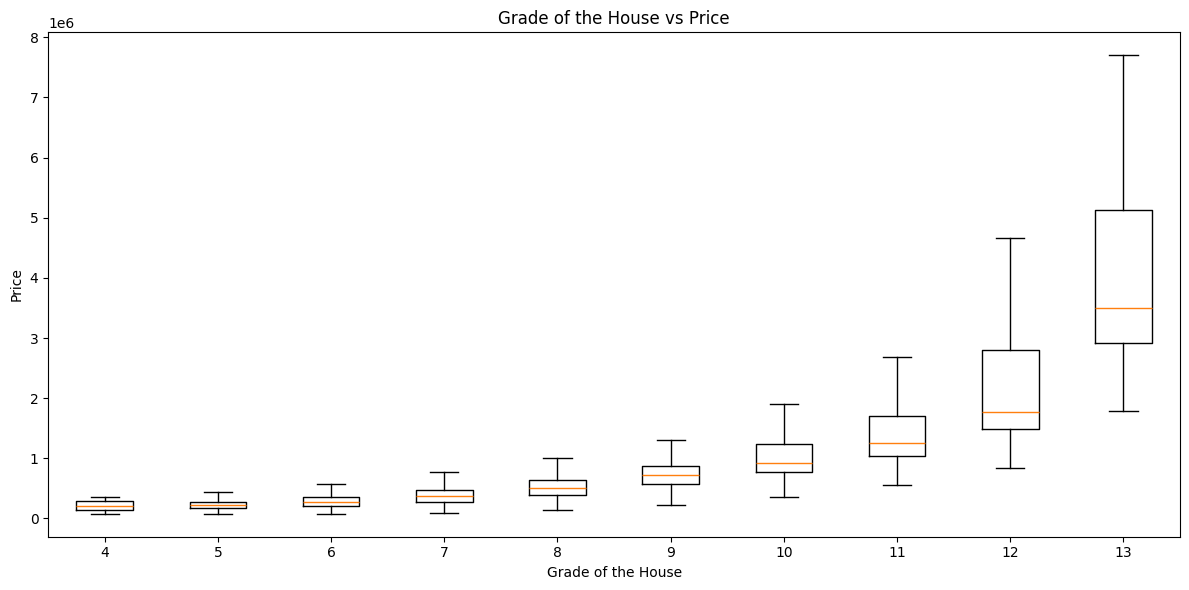

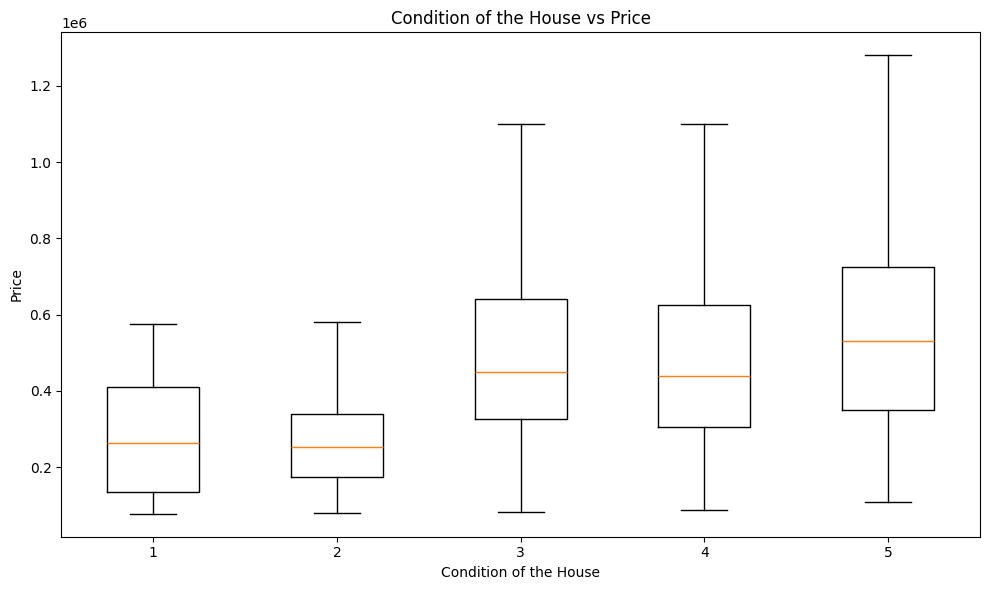

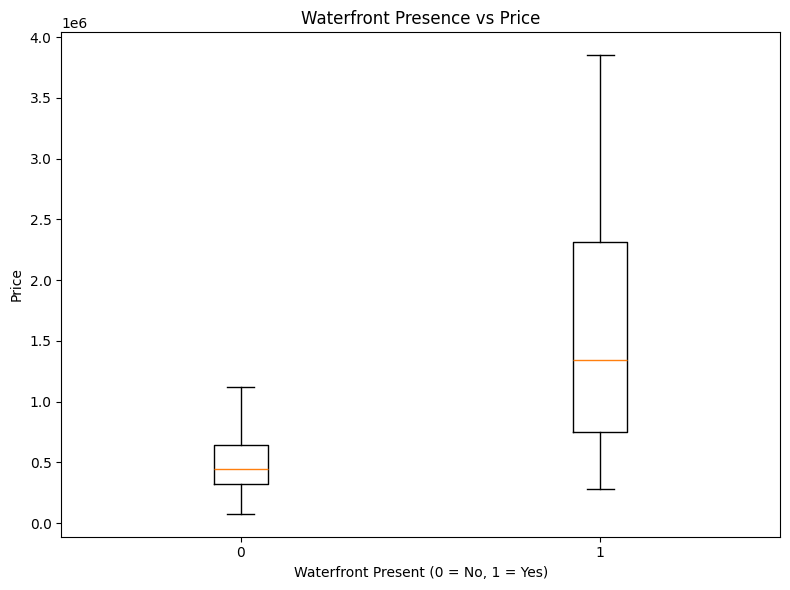

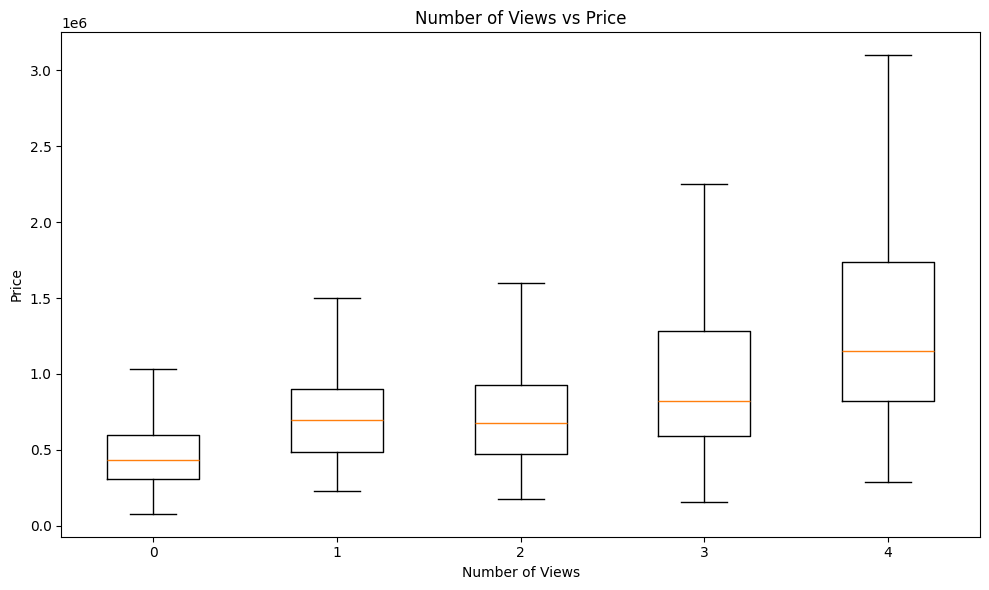

Correlation with Price:
Price                     1.000000
grade of the house        0.671814
number of views           0.395973
waterfront present        0.263687
condition of the house    0.041376
Name: Price, dtype: float64


In [11]:

# 1) Grade vs Price

grade_order = sorted(df_a["grade of the house"].unique())
grade_price_data = [
    df_a.loc[df_a["grade of the house"] == g, "Price"] for g in grade_order
]

plt.figure(figsize=(12, 6))
plt.boxplot(grade_price_data, tick_labels=[str(g) for g in grade_order], showfliers=False)
plt.title("Grade of the House vs Price")
plt.xlabel("Grade of the House")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/grade_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()



# 2) Condition vs Price

condition_order = sorted(df_a["condition of the house"].unique())
condition_price_data = [
    df_a.loc[df_a["condition of the house"] == c, "Price"] for c in condition_order
]

plt.figure(figsize=(10, 6))
plt.boxplot(condition_price_data, tick_labels=[str(c) for c in condition_order], showfliers=False)
plt.title("Condition of the House vs Price")
plt.xlabel("Condition of the House")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/condition_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# 3) Waterfront vs Price
waterfront_order = sorted(df_a["waterfront present"].unique())
waterfront_price_data = [
    df_a.loc[df_a["waterfront present"] == w, "Price"] for w in waterfront_order
]

plt.figure(figsize=(8, 6))
plt.boxplot(waterfront_price_data, tick_labels=[str(w) for w in waterfront_order], showfliers=False)
plt.title("Waterfront Presence vs Price")
plt.xlabel("Waterfront Present (0 = No, 1 = Yes)")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/waterfront_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# 4) Views vs Price
view_order = sorted(df_a["number of views"].unique())
view_price_data = [
    df_a.loc[df_a["number of views"] == v, "Price"] for v in view_order
]

plt.figure(figsize=(10, 6))
plt.boxplot(view_price_data, tick_labels=[str(v) for v in view_order], showfliers=False)
plt.title("Number of Views vs Price")
plt.xlabel("Number of Views")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/views_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# quick numeric support
print("Correlation with Price:")
print(
    df_a[
        ["grade of the house", "condition of the house", "waterfront present", "number of views", "Price"]
    ].corr()["Price"].sort_values(ascending=False)
)

Age, Renovation, Latitude, Longitude vs Price

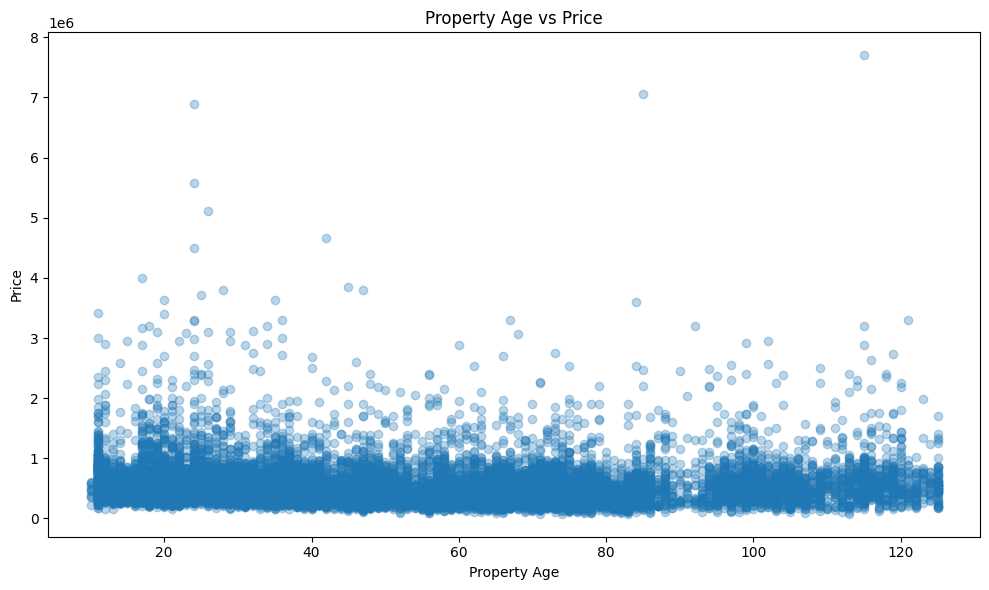

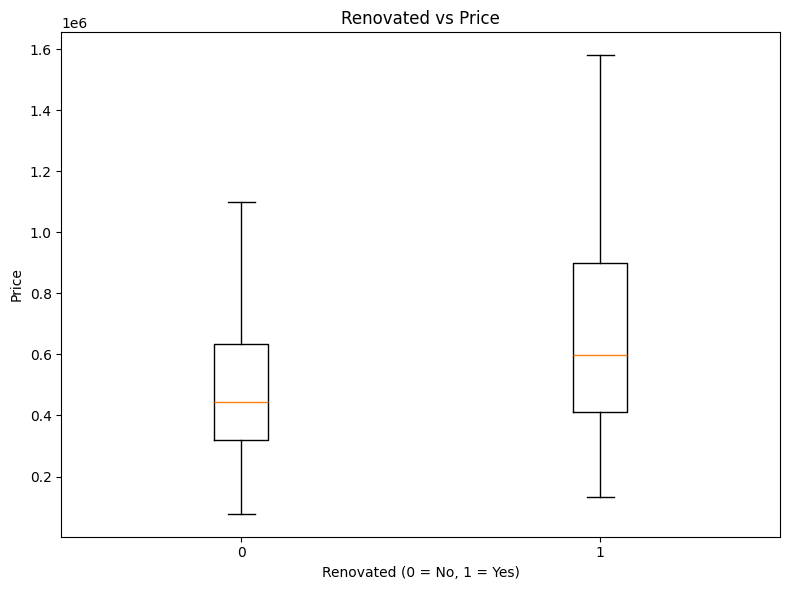

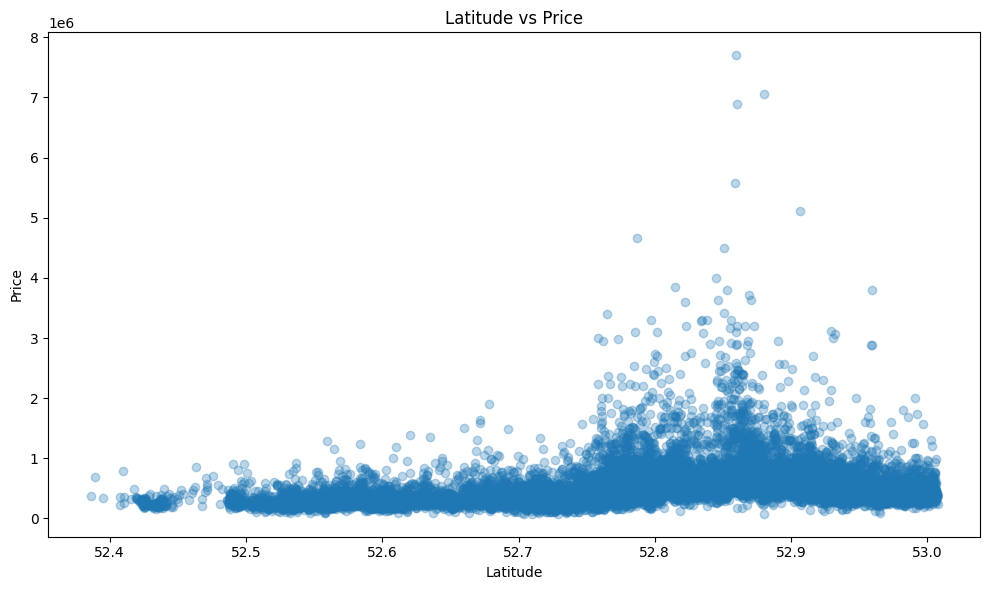

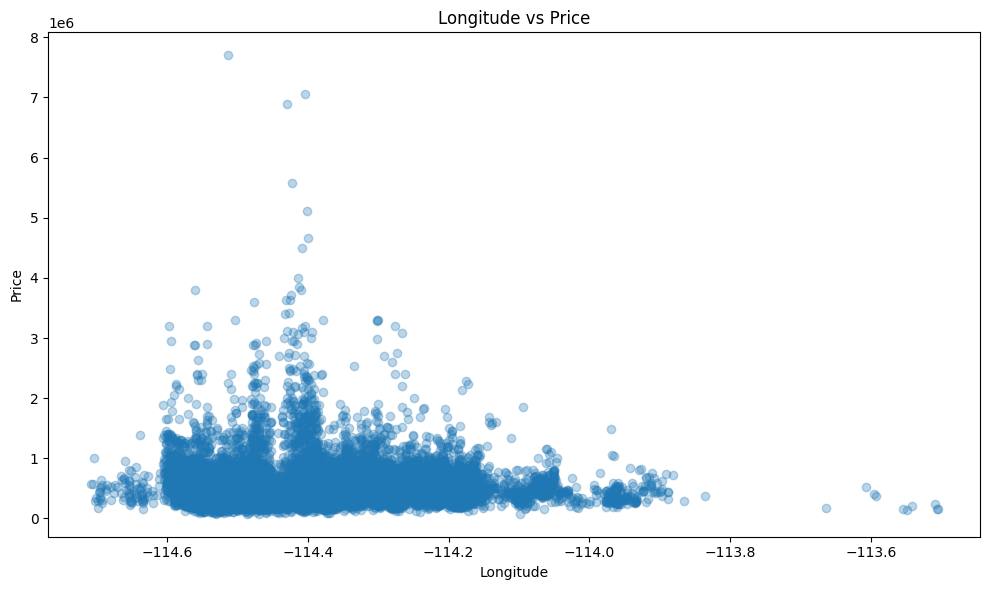

Correlation with Price:
Price           1.000000
Lattitude       0.297490
Renovated       0.132823
Longitude       0.024414
Property_Age   -0.050307
Name: Price, dtype: float64


In [12]:
# 1) Property Age vs Price
plt.figure(figsize=(10, 6))
plt.scatter(df_a["Property_Age"], df_a["Price"], alpha=0.3)
plt.title("Property Age vs Price")
plt.xlabel("Property Age")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/property_age_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# 2) Renovated vs Price
renovated_order = sorted(df_a["Renovated"].unique())
renovated_price_data = [
    df_a.loc[df_a["Renovated"] == r, "Price"] for r in renovated_order
]

plt.figure(figsize=(8, 6))
plt.boxplot(renovated_price_data, tick_labels=[str(r) for r in renovated_order], showfliers=False)
plt.title("Renovated vs Price")
plt.xlabel("Renovated (0 = No, 1 = Yes)")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/renovated_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# 3) Latitude vs Price
plt.figure(figsize=(10, 6))
plt.scatter(df_a["Lattitude"], df_a["Price"], alpha=0.3)
plt.title("Latitude vs Price")
plt.xlabel("Latitude")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/latitude_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# 4) Longitude vs Price
plt.figure(figsize=(10, 6))
plt.scatter(df_a["Longitude"], df_a["Price"], alpha=0.3)
plt.title("Longitude vs Price")
plt.xlabel("Longitude")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/longitude_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# quick numeric support
print("Correlation with Price:")
print(
    df_a[
        ["Property_Age", "Renovated", "Lattitude", "Longitude", "Price"]
    ].corr()["Price"].sort_values(ascending=False)
)

Engineered Features vs Price

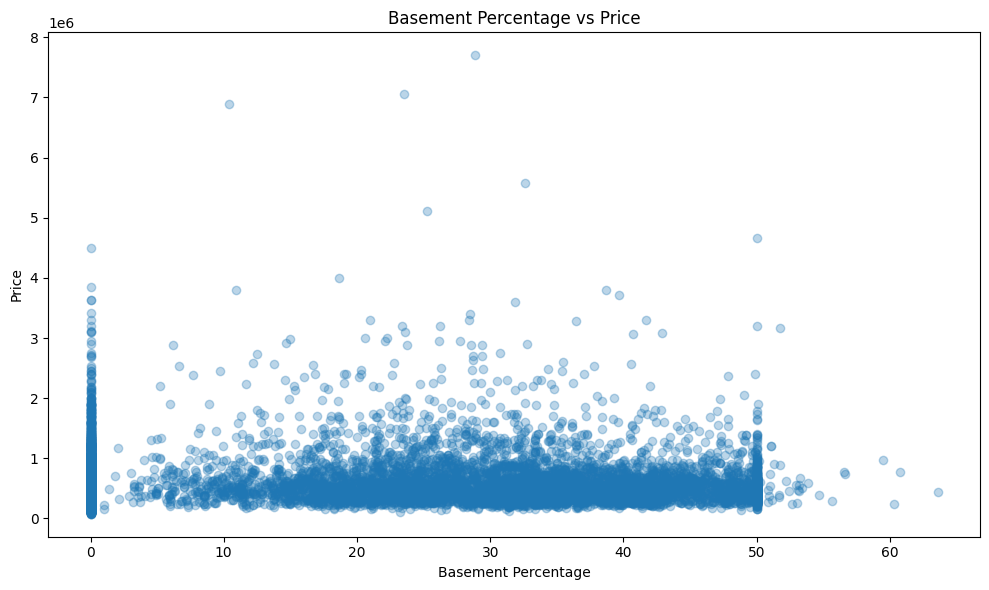

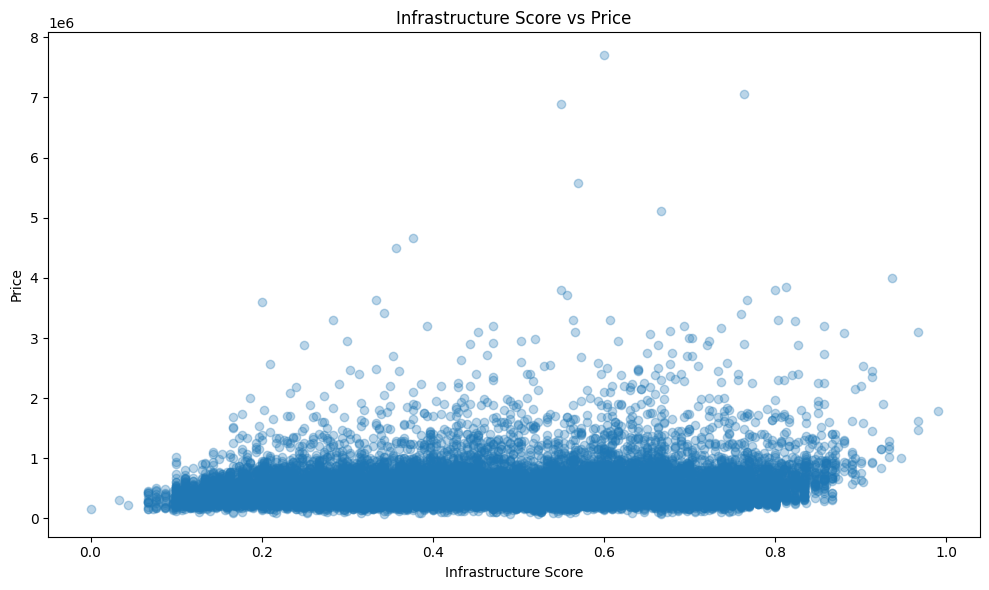

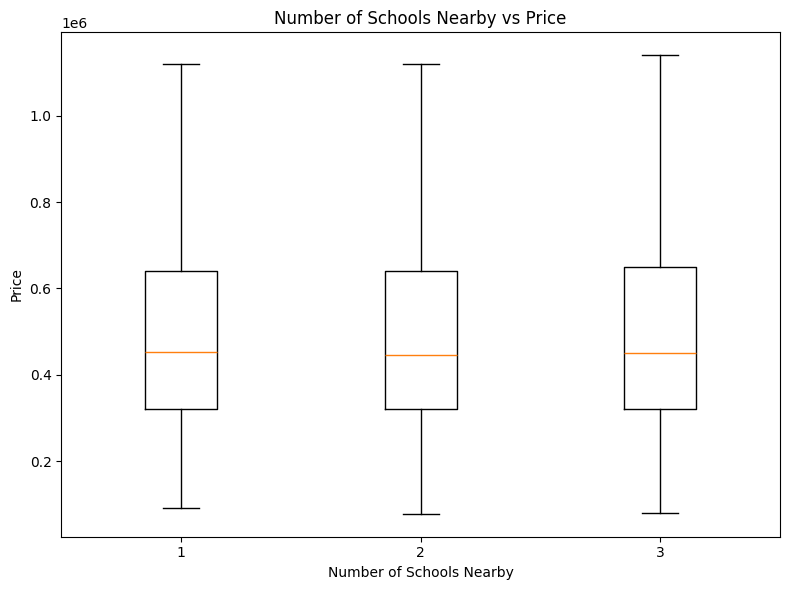

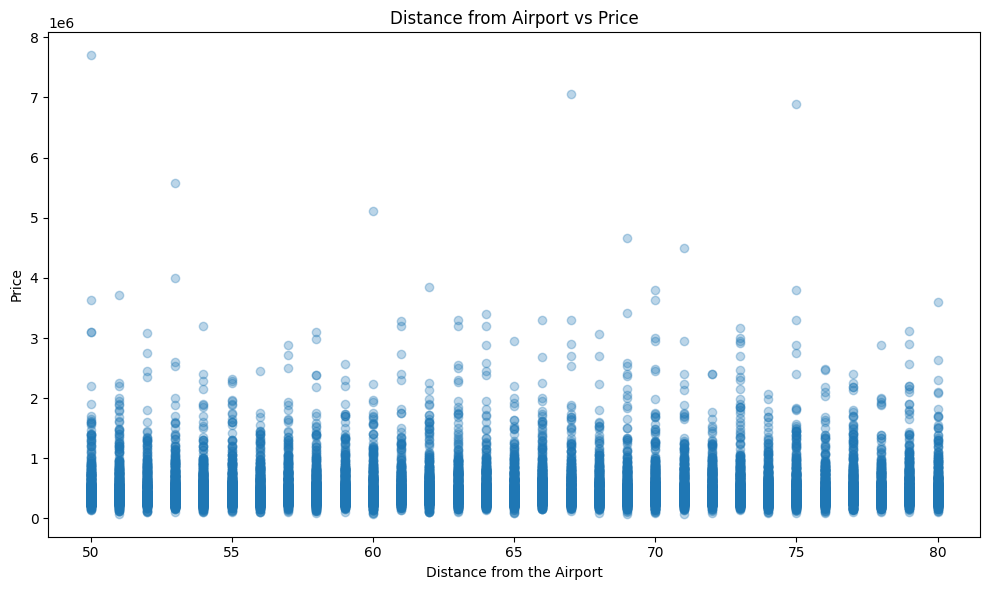

Correlation with Price:
Price                        1.000000
Infrastructure_Score         0.145216
Basement_Percentage          0.134880
Number of schools nearby     0.009890
Distance from the airport    0.003804
Name: Price, dtype: float64


In [13]:
# 1) Basement Percentage vs Price
plt.figure(figsize=(10, 6))
plt.scatter(df_a["Basement_Percentage"], df_a["Price"], alpha=0.3)
plt.title("Basement Percentage vs Price")
plt.xlabel("Basement Percentage")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/basement_percentage_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# 2) Infrastructure Score vs Price
plt.figure(figsize=(10, 6))
plt.scatter(df_a["Infrastructure_Score"], df_a["Price"], alpha=0.3)
plt.title("Infrastructure Score vs Price")
plt.xlabel("Infrastructure Score")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/infrastructure_score_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# 3) Schools Nearby vs Price
school_order = sorted(df_a["Number of schools nearby"].unique())
school_price_data = [
    df_a.loc[df_a["Number of schools nearby"] == s, "Price"] for s in school_order
]

plt.figure(figsize=(8, 6))
plt.boxplot(school_price_data, tick_labels=[str(s) for s in school_order], showfliers=False)
plt.title("Number of Schools Nearby vs Price")
plt.xlabel("Number of Schools Nearby")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/schools_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


# 4) Distance from Airport vs Price
plt.figure(figsize=(10, 6))
plt.scatter(df_a["Distance from the airport"], df_a["Price"], alpha=0.3)
plt.title("Distance from Airport vs Price")
plt.xlabel("Distance from the Airport")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/airport_distance_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()


print("Correlation with Price:")
print(
    df_a[
        [
            "Basement_Percentage",
            "Infrastructure_Score",
            "Number of schools nearby",
            "Distance from the airport",
            "Price"
        ]
    ].corr()["Price"].sort_values(ascending=False)
)

# orrelation Heatmap & Outlier Review

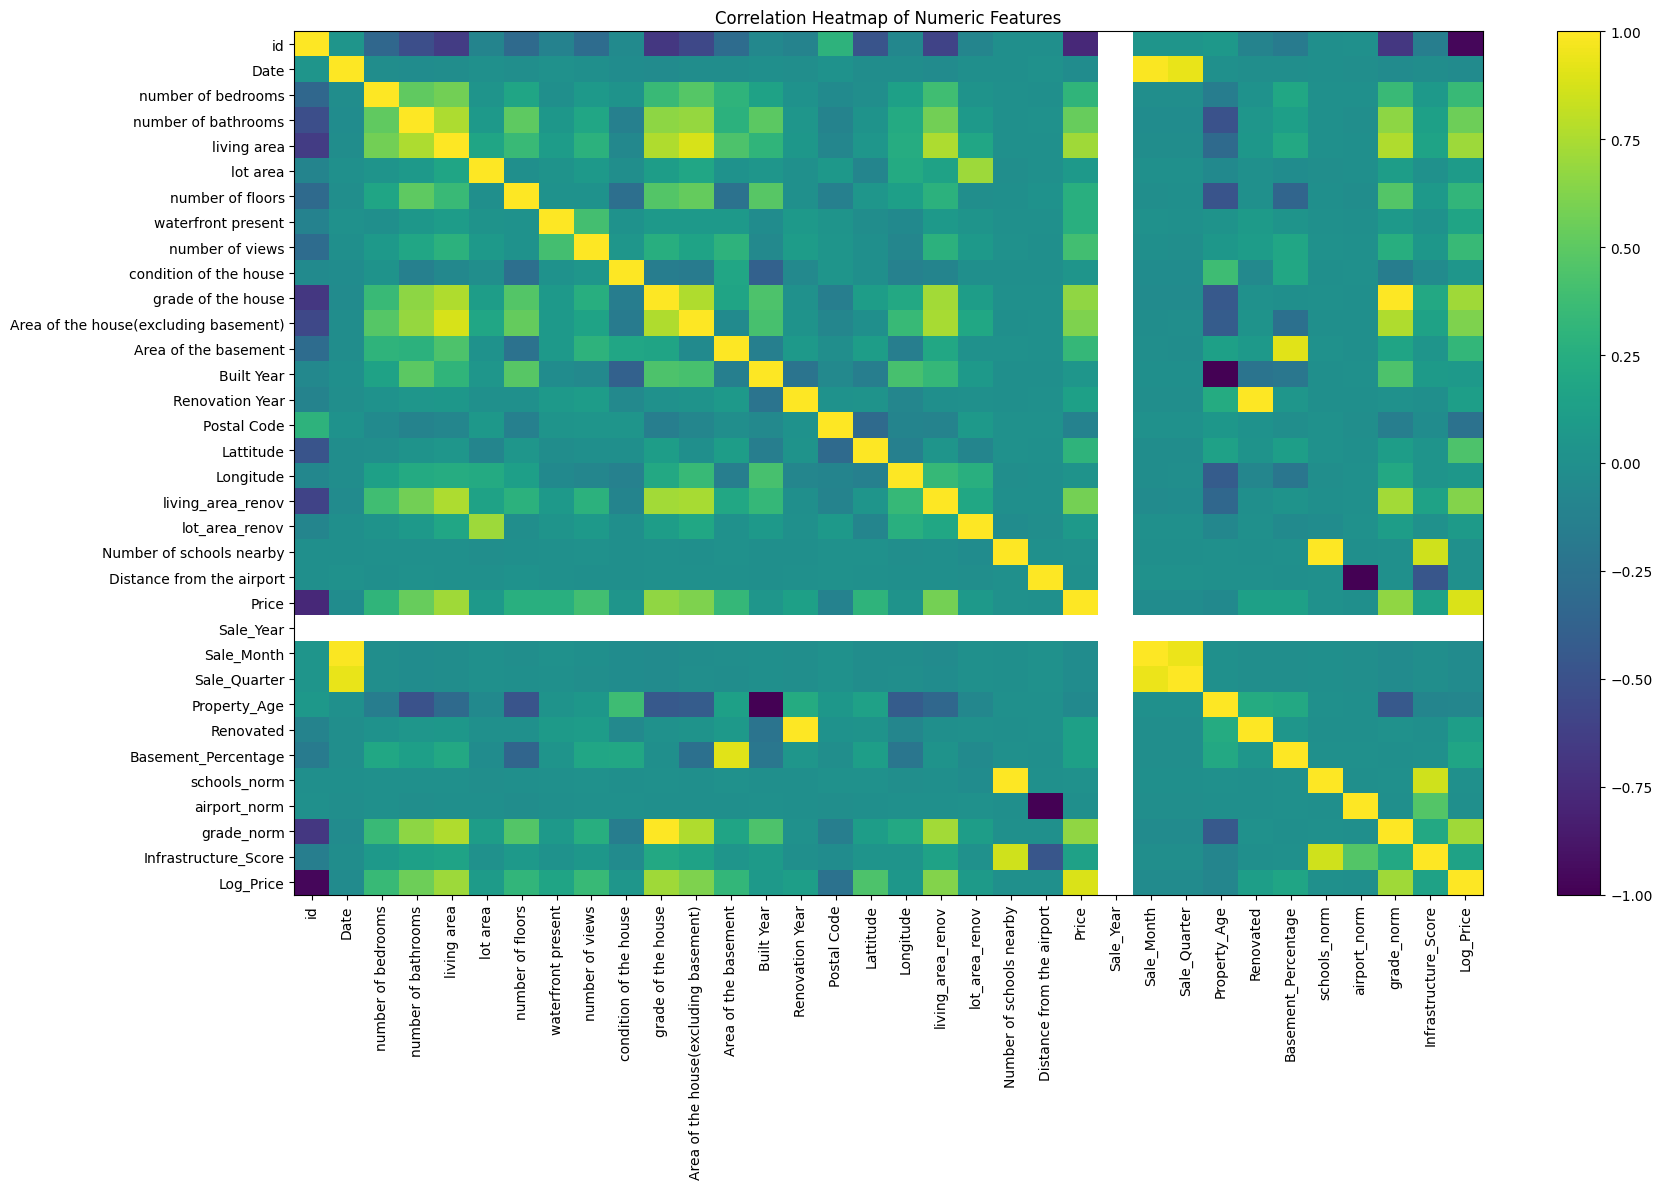

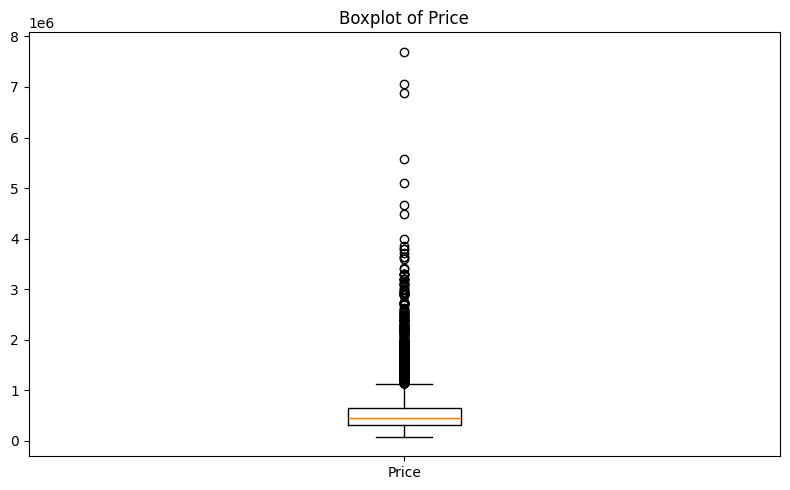

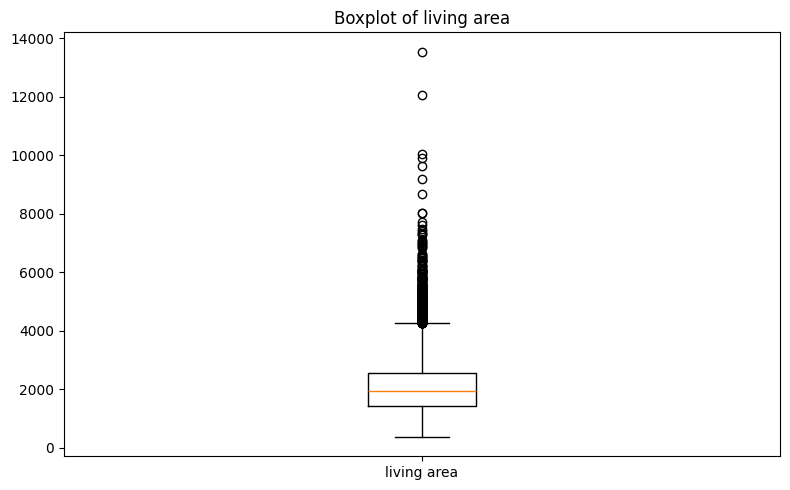

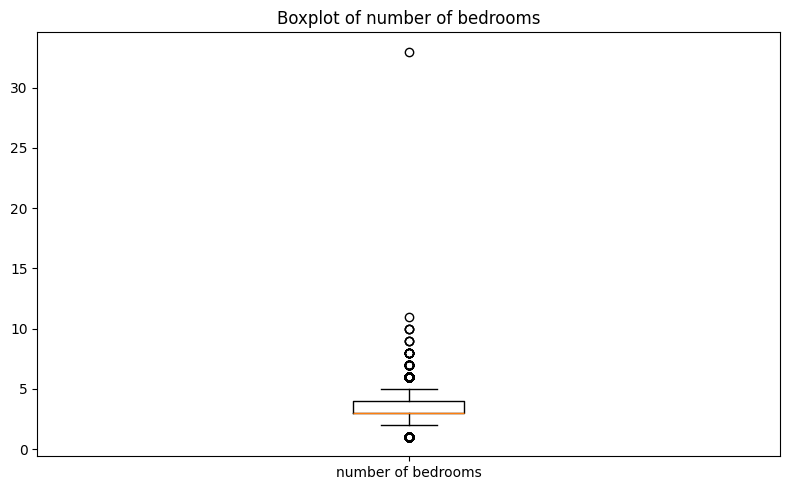

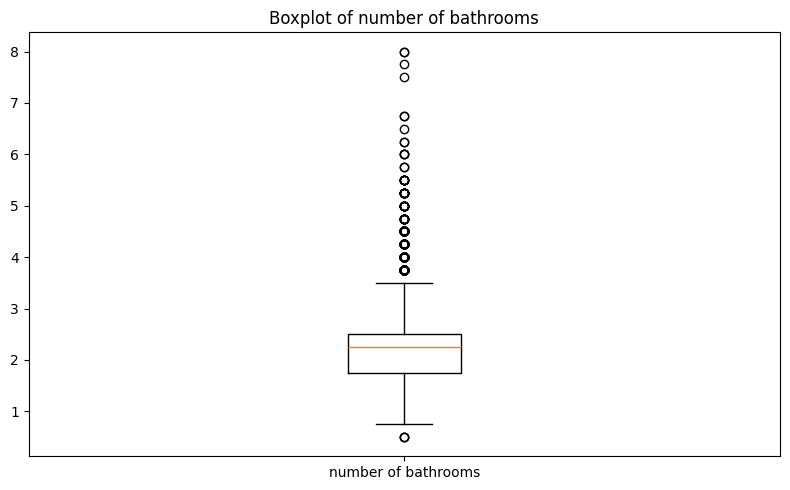

IQR Outlier Summary:

Price:
  Q1: 320000.0
  Q3: 645000.0
  IQR: 325000.0
  Lower_Bound: -167500.0
  Upper_Bound: 1132500.0
  Outlier_Count: 761

living area:
  Q1: 1440.0
  Q3: 2570.0
  IQR: 1130.0
  Lower_Bound: -255.0
  Upper_Bound: 4265.0
  Outlier_Count: 395

number of bedrooms:
  Q1: 3.0
  Q3: 4.0
  IQR: 1.0
  Lower_Bound: 1.5
  Upper_Bound: 5.5
  Outlier_Count: 361

number of bathrooms:
  Q1: 1.75
  Q3: 2.5
  IQR: 0.75
  Lower_Bound: 0.625
  Upper_Bound: 3.625
  Outlier_Count: 379



In [14]:
# 1) Correlation Heatmap
corr_matrix = df_a.corr(numeric_only=True)

plt.figure(figsize=(18, 12))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


# 2) Outlier Review Boxplots
outlier_cols = ["Price", "living area", "number of bedrooms", "number of bathrooms"]

for col in outlier_cols:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df_a[col], tick_labels=[col], showfliers=True)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    safe_name = col.replace(" ", "_").replace("/", "_")
    plt.savefig(f"{FIG_DIR}/boxplot_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()


# 3) IQR-based Outlier Counts
def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": int(count)
    }

print("IQR Outlier Summary:\n")
for col in outlier_cols:
    stats = outlier_count_iqr(df_a[col])
    print(f"{col}:")
    for k, v in stats.items():
        print(f"  {k}: {v}")
    print()